In [1]:
from keras.utils import image_dataset_from_directory
from tensorflow.keras.preprocessing import image
from sklearn.utils.class_weight import compute_class_weight
from keras.applications.vgg16 import VGG16
from keras.applications.vgg16 import preprocess_input
from keras.applications import vgg16
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import RandomFlip
from tensorflow.keras.layers import RandomZoom
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomTranslation
from tensorflow.keras.layers import Rescaling,Resizing
from sklearn.metrics import classification_report,confusion_matrix
from tensorflow.keras.models import load_model

import numpy as np
import matplotlib.pyplot as plt
import prettypyplot as pplt
import seaborn as sns

import cv2
import os

In [2]:
train_ds=image_dataset_from_directory('./train',seed=42,batch_size=16,image_size=(363,360))
val_ds=image_dataset_from_directory('./val',seed=42,batch_size=16,image_size=(363,360),label_mode='int')
class_names=train_ds.class_names

Found 13671 files belonging to 8 classes.
Found 3421 files belonging to 8 classes.


In [ ]:
for x, y in train_ds.take(1):
    print("Image batch shape:", x.shape)   
    print (train_ds.class_names[y[0]])
    print("Label batch shape:", y.shape) 

Image batch shape: (16, 363, 360, 3)
monocyte
Label batch shape: (16,)


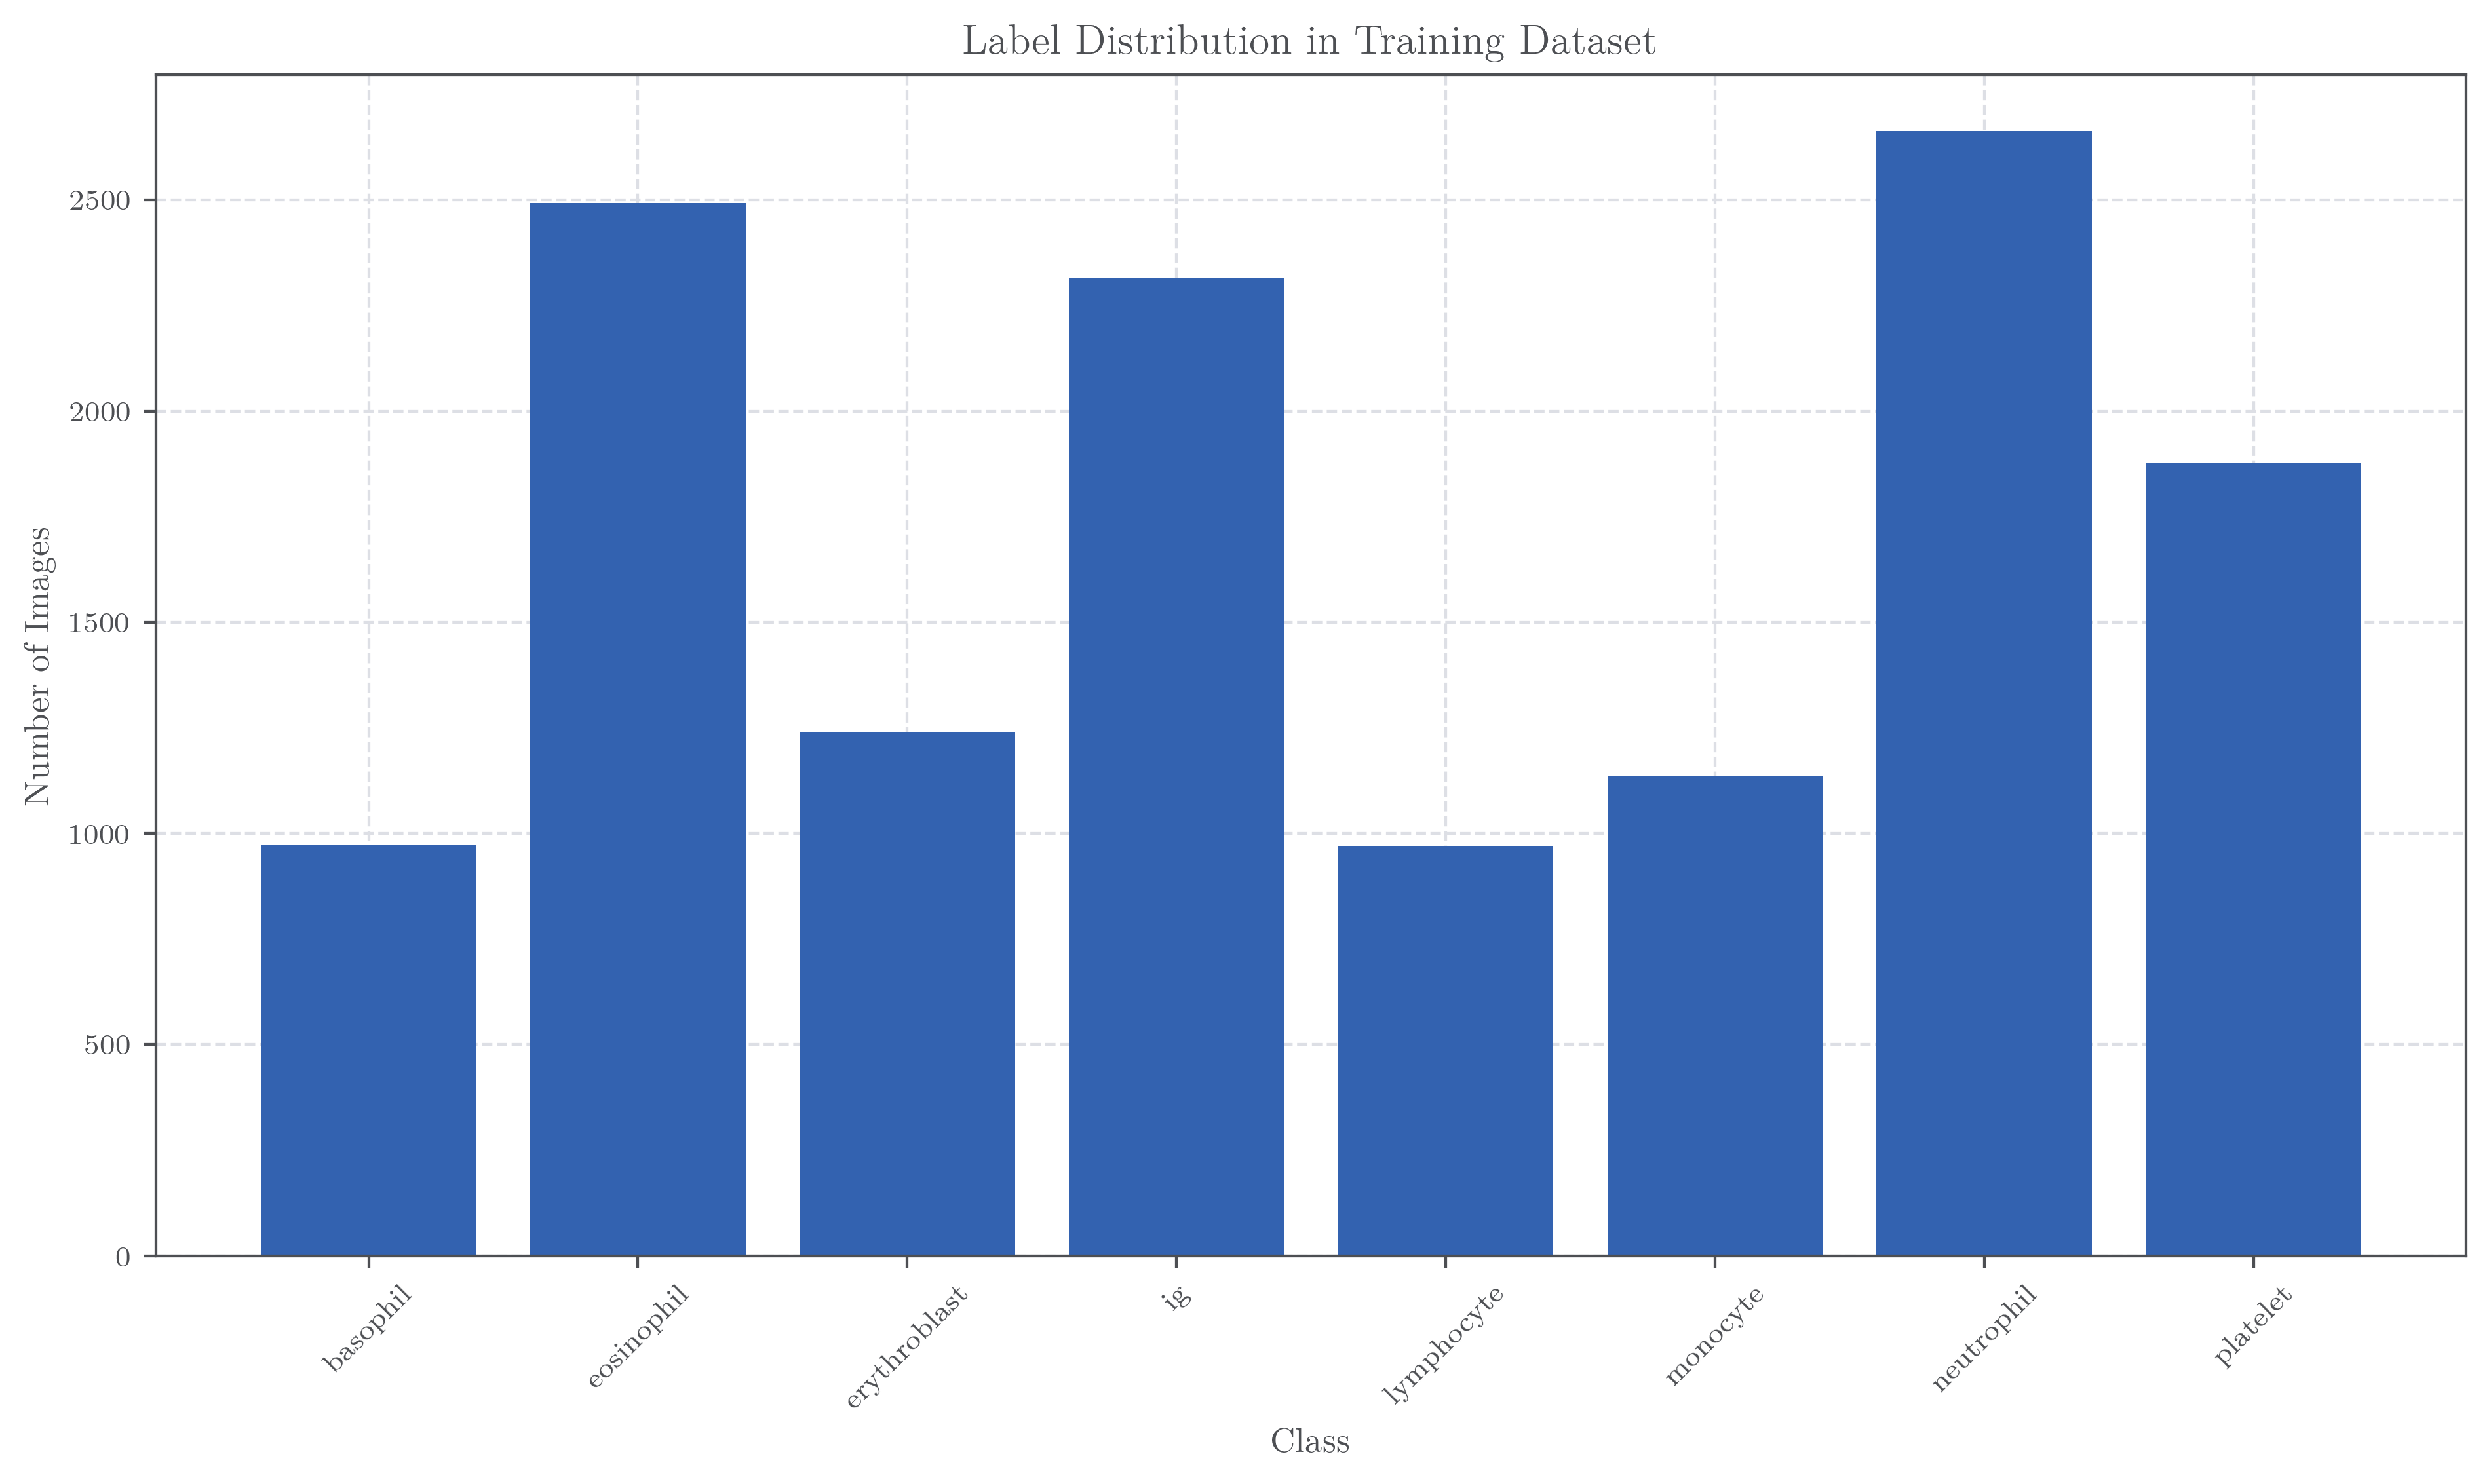

In [ ]:
from collections import Counter
pplt.use_style()
all_labels = []
for _, labels in train_ds:
    all_labels.extend(labels.numpy())

label_counts = Counter(all_labels)

class_names = train_ds.class_names
sorted_labels = sorted(label_counts.items())

labels, counts = zip(*sorted_labels)
label_names = [class_names[i] for i in labels]

plt.figure(figsize=(10, 6))
plt.bar(label_names, counts)
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Label Distribution in Training Dataset')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
#preprocessing the oversampled data
train_ds=train_ds.map(lambda x,y:(preprocess_input(x),y))
val_ds=val_ds.map(lambda x,y:(preprocess_input(x),y))

In [26]:
base_model=VGG16(weights='imagenet',include_top=False)
base_model.trainable=False
inputs=Input(shape=(363,360,3))
x=RandomRotation(0.1)(inputs)
x=RandomTranslation(height_factor=0.1,width_factor=0.1)(x)
x=RandomZoom(0.1)(x)
x=RandomFlip('horizontal')(x)
x=Resizing(64,64)(x)
x=Rescaling(1/255)(x)

x=base_model(x)
x=GlobalAveragePooling2D()(x)
x=Dense(1024,activation='relu')(x)
x=Dropout(rate=0.2)(x)
x=Dense(512,activation='relu')(x)
x=Dropout(rate=0.2)(x)
outputs=Dense(8,activation='softmax')(x)
model=Model(inputs=inputs,outputs=outputs)

In [27]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [28]:
history_model=model.fit(train_ds,validation_data=val_ds,epochs=5)

Epoch 1/5
855/855 ━━━━━━━━━━━━━━━━━━━━ 227s 264ms/step - accuracy: 0.5478 - loss: 1.2247 - val_accuracy: 0.7241 - val_loss: 0.7535
Epoch 2/5
855/855 ━━━━━━━━━━━━━━━━━━━━ 315s 369ms/step - accuracy: 0.7014 - loss: 0.8097 - val_accuracy: 0.7556 - val_loss: 0.6761
Epoch 3/5
855/855 ━━━━━━━━━━━━━━━━━━━━ 294s 344ms/step - accuracy: 0.7211 - loss: 0.7707 - val_accuracy: 0.7439 - val_loss: 0.6793
Epoch 4/5
855/855 ━━━━━━━━━━━━━━━━━━━━ 223s 261ms/step - accuracy: 0.7313 - loss: 0.7363 - val_accuracy: 0.7641 - val_loss: 0.6292
Epoch 5/5
855/855 ━━━━━━━━━━━━━━━━━━━━ 223s 260ms/step - accuracy: 0.7430 - loss: 0.7114 - val_accuracy: 0.7694 - val_loss: 0.6300


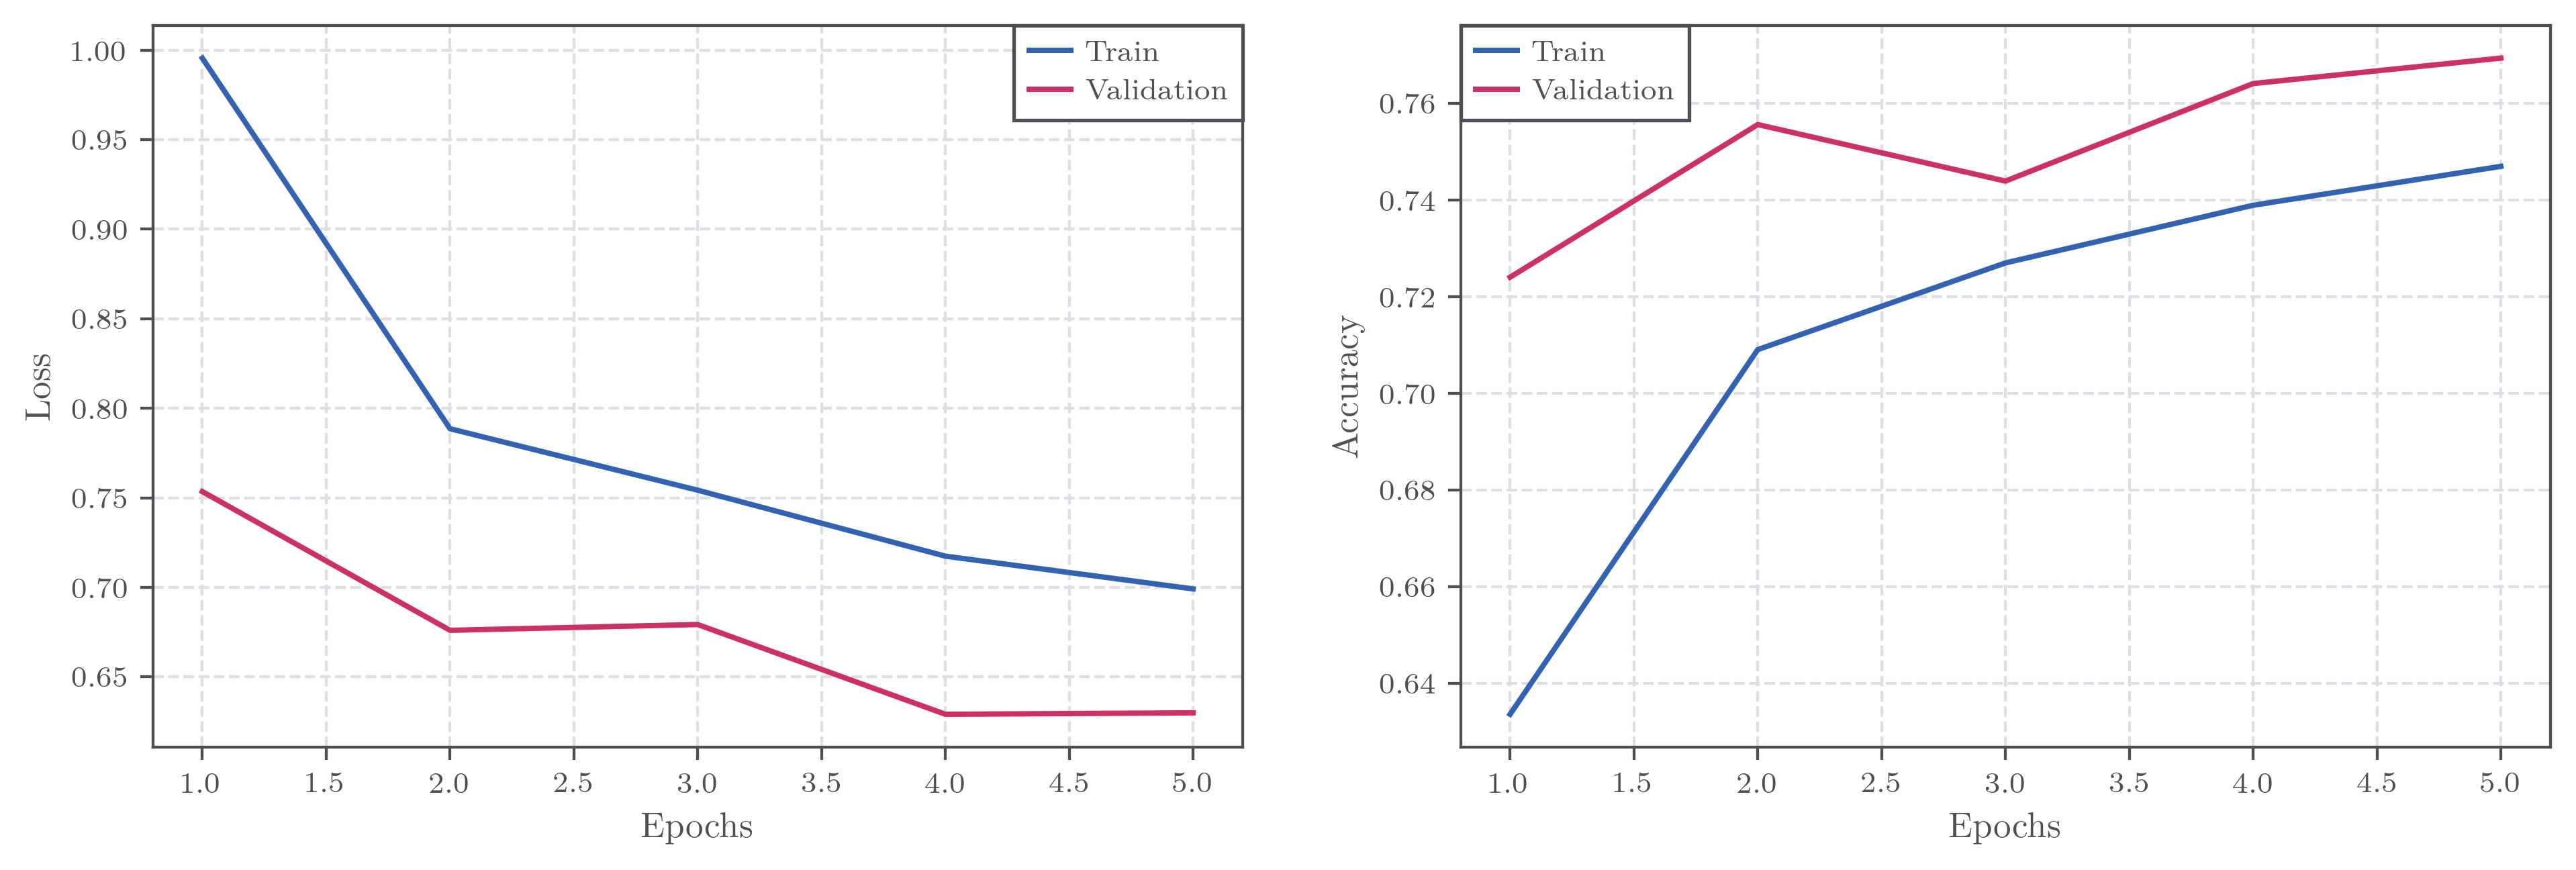

In [30]:
pplt.use_style()
loss=history_model.history['loss']
val_loss=history_model.history['val_loss']
accuracy=history_model.history['accuracy']
val_accuracy=history_model.history['val_accuracy']
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.plot(np.arange(1,6),loss,label='Train')
plt.plot(np.arange(1,6),val_loss,label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend();
plt.subplot(122)
plt.plot(np.arange(1,6),accuracy,label='Train')
plt.plot(np.arange(1,6),val_accuracy,label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend();

In [31]:
model.save("first_model_vgg16.h5")

In [3]:
model=load_model('first_model_vgg16.h5')

In [4]:
def get_predictions_and_labels(dataset):
    true_labels = []
    pred_labels = []

    for images, labels in dataset:
        
        preds = model.predict(images, verbose=0)  # Get the model's predictions
        pred_labels.extend(np.argmax(preds, axis=-1))  # Get the predicted labels (argmax)

        true_labels.extend(labels.numpy())  # Get the true labels

    return np.array(true_labels), np.array(pred_labels)

y_true, y_pred = get_predictions_and_labels(val_ds)

In [5]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    basophil       0.37      0.60      0.45       244
  eosinophil       0.31      0.97      0.47       624
erythroblast       0.88      0.07      0.14       311
          ig       0.53      0.04      0.08       579
  lymphocyte       0.79      0.13      0.22       243
    monocyte       0.00      0.00      0.00       284
  neutrophil       0.80      0.45      0.58       666
    platelet       0.72      0.92      0.81       470

    accuracy                           0.46      3421
   macro avg       0.55      0.40      0.34      3421
weighted avg       0.56      0.46      0.38      3421



C:\Users\ahmed\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ahmed\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ahmed\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

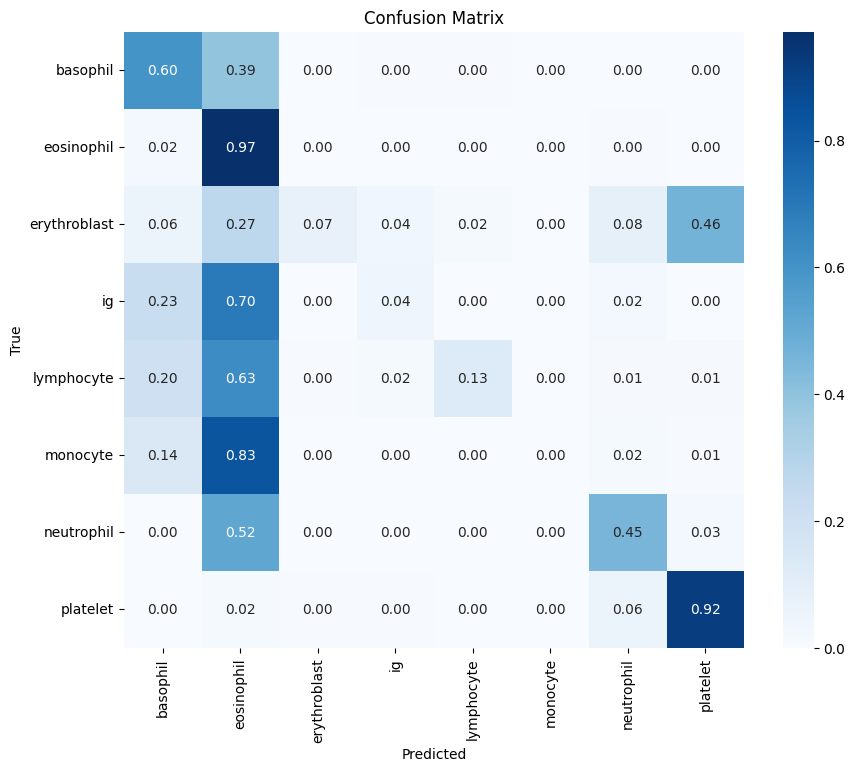

In [6]:
cm = confusion_matrix(y_true, y_pred,normalize='true')
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, xticklabels=class_names, yticklabels=class_names, fmt='.2f', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()